# ElasticNet (L1 + L2)

**Flow:** correlated feature groups → mix L1/L2 → compare coefficient behavior.

ElasticNet mixes Lasso feature selection with Ridge-like stability. `l1_ratio=0` is Ridge-like; `l1_ratio=1` is Lasso-like.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.metrics import r2_score, confusion_matrix
rng=np.random.default_rng(42)

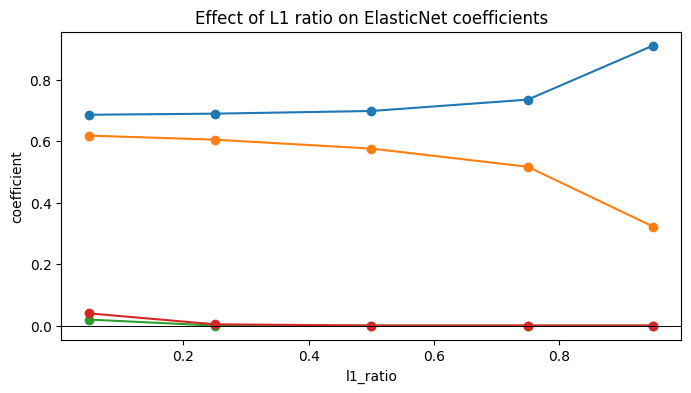

In [2]:
z=rng.normal(size=130); X=np.c_[z+.1*rng.normal(size=130),z+.1*rng.normal(size=130),rng.normal(size=130),rng.normal(size=130)]; y=2*z+rng.normal(0,1,130); ratios=[.05,.25,.5,.75,.95]; cs=[]
for r in ratios:
 p=Pipeline([('scale',StandardScaler()),('enet',ElasticNet(alpha=.25,l1_ratio=r,max_iter=10000))]).fit(X,y); cs.append(p.named_steps['enet'].coef_)
plt.figure(figsize=(8,4)); plt.plot(ratios,cs,'o-'); plt.axhline(0,color='k',lw=.7); plt.title('Effect of L1 ratio on ElasticNet coefficients'); plt.xlabel('l1_ratio'); plt.ylabel('coefficient'); plt.show()

Use `ElasticNetCV` when both alpha and the L1/L2 balance need tuning. The following plot compares the three coefficient patterns on the same scaled data.

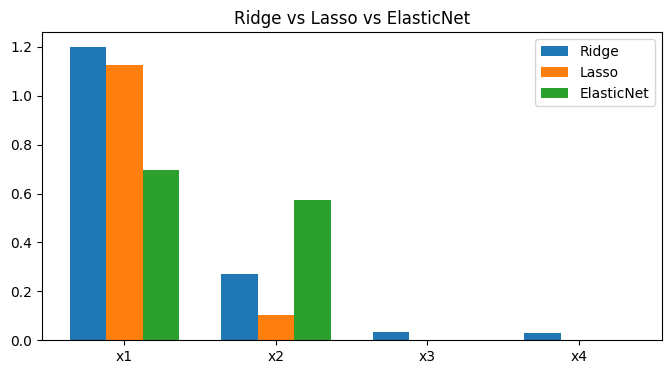

In [3]:
models={'Ridge':Ridge(alpha=.25),'Lasso':Lasso(alpha=.25,max_iter=10000),'ElasticNet':ElasticNet(alpha=.25,l1_ratio=.5,max_iter=10000)}; values=[]
for name,m in models.items():
 p=Pipeline([('scale',StandardScaler()),('m',m)]).fit(X,y); values.append(p.named_steps['m'].coef_)
plt.figure(figsize=(8,4)); w=.24; pos=np.arange(X.shape[1]);
for i,(name,c) in enumerate(zip(models,values)): plt.bar(pos+(i-1)*w,c,w,label=name)
plt.axhline(0,color='k',lw=.7); plt.xticks(pos,[f'x{i+1}' for i in pos]); plt.legend(); plt.title('Ridge vs Lasso vs ElasticNet'); plt.show()